## Normalizer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/normalizer.ipynb)

This guide explains the tools available to normalize feature values for training
GNN models.

You'll learn how to compute feature statistics either in-memory using Beam, to
use those feature statistics to initialize "normalizers", and finally, how to
use the "auto-normalizer" to automatically construct all the normalizers to
consume a graph.

## Importing libraries

In [1]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import dgf  # Import Graph Flow
import numpy as np

## Load some data

Let's start by loading a toy dataset.

In [2]:
# Download the Mag graph from the OGB repo.
graph, schema = dgf.io.fetch_ogb_graph("mag")

Caching mag graph at /tmp/gf_fetch/mag.cache
OGB dependency not available. Downloading graph from CNS.


The computation of feature statistics and the normalization of features
relies extensively on both the "format" and "semantic" of the features. Make
sure those are correctly configured.

In [3]:
dgf.print.schema(schema)

Graph Schema:

Node Sets:
  author:
    | Feature   | Format   | Semantic   | Shape   | Num cat. vals   |
    |-----------|----------|------------|---------|-----------------|
    | #id       | BYTES    | PRIMARY_ID | None    | None            |

  field_of_study:
    | Feature   | Format   | Semantic   | Shape   | Num cat. vals   |
    |-----------|----------|------------|---------|-----------------|
    | #id       | BYTES    | PRIMARY_ID | None    | None            |

  institution:
    | Feature   | Format   | Semantic   | Shape   | Num cat. vals   |
    |-----------|----------|------------|---------|-----------------|
    | #id       | BYTES    | PRIMARY_ID | None    | None            |

  paper:
    | Feature   | Format     | Semantic    | Shape   | Num cat. vals   |
    |-----------|------------|-------------|---------|-----------------|
    | #id       | BYTES      | PRIMARY_ID  | None    | None            |
    | #split    | BYTES      | CATEGORICAL | None    | None           

## Generate some graph samples

First, we need to get feature statistics (e.g., quantiles, dictionaries) for the
node features. You can compute them these from the original graph or from graph
samples.

While using the full graph is faster and easier, the results might not match the
data distribution the GNN model actually sees, and it is harder to compute
statistics on a sample of data. In this tutorial, we will show the graph sample
solution.

First, we need to define a generator of graph samples. See the sampler tutorial
for more details.

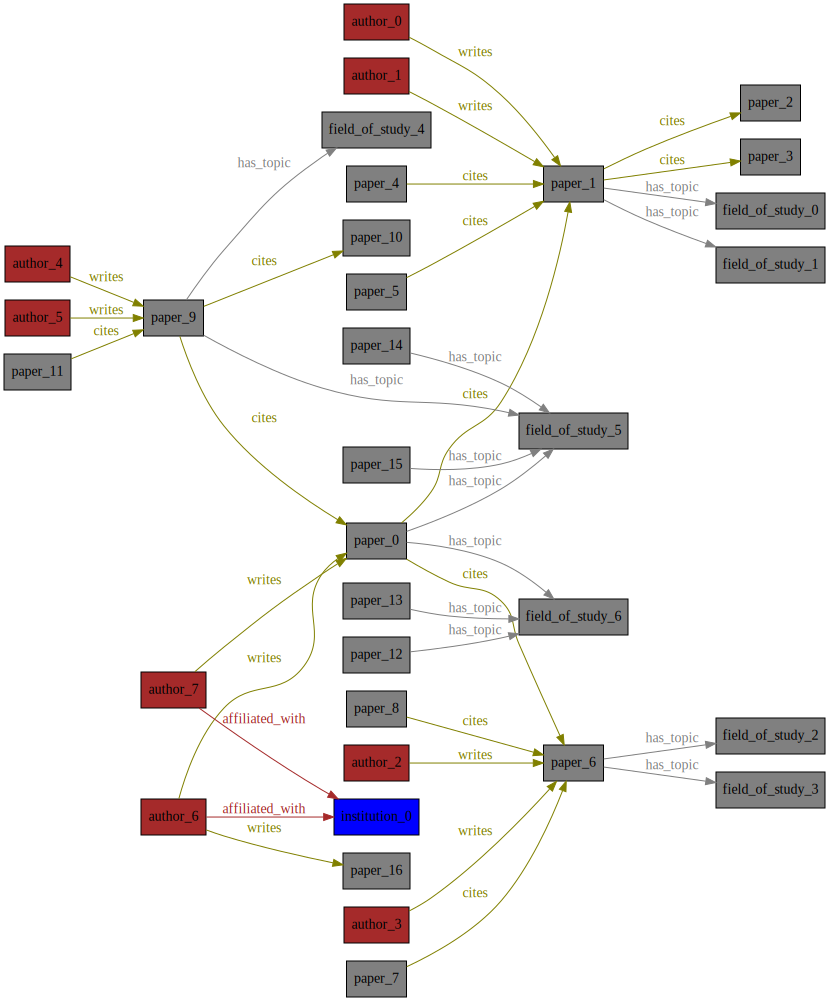

In [4]:
# Create a sampler

sampler = dgf.sampling.create_sampler(
    graph=graph,
    schema=schema,
    plan=dgf.sampling.SimpleSamplingConfig(
        seed_nodeset="paper",
        num_hops=2,
        hop_width=2,
        reverse=True,
    ),
    batch_size=8,
)


# Create a generator of graph samples.
def sample_generator(num_batches: int = 50):
  num_paper_nodes = graph.node_sets["paper"].num_nodes
  for _ in range(num_batches):
    seed_node_idxs = np.random.choice(num_paper_nodes, size=8, replace=False)
    samples = sampler.sample(seed_node_idxs)
    for sample in samples:
      yield sample


# Test the generate by plotting a graph sample.
for sample in sample_generator():
  break
dgf.plot.plot_graph(sample, schema, features=False)

## In-memory computation of feature statistics

In [5]:
feature_stats = dgf.analyse.feature_statistics_from_graphs(
    sample_generator(num_batches=50), schema
)
feature_stats

GraphFeatureStatistics:
  Node Sets (4):
    'author':
      '#id': count=2843, min=nan, max=nan
    'field_of_study':
      '#id': count=2895, min=nan, max=nan
    'institution':
      '#id': count=709, min=nan, max=nan
    'paper':
      '#id': count=7428, min=nan, max=nan
      '#split': count=7428, min=nan, max=nan, dictionary=(3)['train': 6173, 'valid': 674, 'test': 581]
      'feat': count=7428, min=nan, max=nan
      'labels': count=7428, min=0.0000, max=348.0000
      'year': count=7428, min=2010.0000, max=2019.0000, quantiles=(100)[2010.0000, 2010.0000, 2010.0000, ..., 2019.0000, 2019.0000, 2019.0000]

**Remark:**

-   The type of statistics gathered depends on the data type. For example,
    `year` is a numerical value, so you should find its quantiles. However,
    because `feat` is an embedding, you only need to find the count of
    non-missing values.
-   To compute feature statistics from a single graph, you can call
    `dgf.analyse.feature_statistics_from_graphs([graph], schema)` (or
    equivalently, `dgf.analyse.feature_statistics`).

In [6]:
feature_stats = dgf.analyse.feature_statistics(graph, schema)
feature_stats

GraphFeatureStatistics:
  Node Sets (4):
    'author':
      '#id': count=1134649, min=nan, max=nan
    'field_of_study':
      '#id': count=59965, min=nan, max=nan
    'institution':
      '#id': count=8740, min=nan, max=nan
    'paper':
      '#id': count=736389, min=nan, max=nan
      '#split': count=736389, min=nan, max=nan, dictionary=(3)['train': 629571, 'valid': 64879, 'test': 41939]
      'feat': count=736389, min=nan, max=nan
      'labels': count=736389, min=0.0000, max=348.0000
      'year': count=736389, min=2010.0000, max=2019.0000, quantiles=(100)[2010.0000, 2010.0000, 2010.0000, ..., 2019.0000, 2019.0000, 2019.0000]

## Create a feature normalizer

Various feature normalizers are available in `dgf.transform`. For example,
`dgf.transform.SoftQuantileNormalizer` normalizes numerical values using the
soft-quantile method, while `dgf.transform.DictionaryIndexNormalizer` can
normalize categorical values.

As an example, let's create a `SoftQuantileNormalizer` for the `year` feature.

In [ ]:
year_normalizer = dgf.transform.SoftQuantileNormalizer.create(
    feature_name="year",
    input_schema=schema.node_sets["paper"].features["year"],
    input_stats=feature_stats.node_sets["paper"].features["year"],
)

SoftQuantileNormalizer(input_feature='year', type='SoftQuantileNormalizer', output_feature_name='year_SOFT_QUANTILE', output_shape=None, quantiles=array([2010., 2011., 2012., 2013., 2014., 2015., 2016., 2017., 2018.,
       2019.], dtype=float32))

Let's normalize some values:

In [ ]:
# Raw values
raw_values = graph.node_sets["paper"].features["year"][:10]
raw_values

array([2015, 2012, 2012, 2010, 2011, 2011, 2014, 2013, 2012, 2010])

In [ ]:
year_normalizer.normalize_numpy(raw_values)

{'year_SOFT_QUANTILE': array([0.5555556 , 0.22222222, 0.22222222, 0.        , 0.11111111,
        0.11111111, 0.44444445, 0.33333334, 0.22222222, 0.        ],
       dtype=float32)}

**Remark:**

-   A normalizer might take one input feature and produce several output
    features. This is why the output is a dictionary.

If you work with TensorFlow, you might use the TensorFlow version of the
normalization. This is great for serializing GNN model in TensorFlow Saved
Models:

In [ ]:
import tensorflow as tf

year_normalizer.normalize_tensorflow(tf.constant(raw_values))

{'year_SOFT_QUANTILE': <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.5555556 , 0.22222222, 0.22222222, 0.        , 0.11111111,
        0.11111111, 0.44444445, 0.33333334, 0.22222222, 0.        ],
       dtype=float32)>}

The normalizer can also produce the schema of its output:

In [ ]:
year_normalizer.output_schema()

{'year_SOFT_QUANTILE': FeatureSchema(format=<FeatureFormat.FLOAT_32: 'FLOAT_32'>, semantic=<FeatureSemantic.EMBEDDING: 'EMBEDDING'>, shape=None, num_categorical_values=None, is_utf8_string=False)}

Like all GF configurations, normalizers can be serialized from / to json:

In [ ]:
year_normalizer.to_json()

'{"input_feature": "year", "type": "SoftQuantileNormalizer", "output_feature_name": "year_SOFT_QUANTILE", "output_shape": null, "quantiles": [2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0]}'

## Auto-normalization

Instead of defining individual normalizers for all the features of a graph, we
can use the auto-normalizer.

In [ ]:
auto_normalizer = dgf.transform.auto_normalize(schema, feature_stats)
auto_normalizer

[Warning] No normalizer created for node set 'author', feature '#id'.
[Warning] No normalizer created for node set 'paper', feature '#id'.
[Warning] No normalizer created for node set 'field_of_study', feature '#id'.
[Warning] No normalizer created for node set 'institution', feature '#id'.


GraphNormalizer(config=GraphNormalizerConfig(nodesets={'author': NodeSetNormalizerConfig(normalizers=[]), 'paper': NodeSetNormalizerConfig(normalizers=[DictionaryIndexNormalizer(input_feature='#split', type='DictionaryIndexNormalizer', dictionary_map={'train': 0, 'valid': 1, 'test': 2}, out_of_vocab_value=3, output_shape=None, output_feature_name='#split_INDEX', tf_table=None), IdentityNormalizer(input_feature='labels', type='IdentityNormalizer', input_schema=FeatureSchema(format=<FeatureFormat.INTEGER_64: 'INTEGER_64'>, semantic=<FeatureSemantic.CATEGORICAL: 'CATEGORICAL'>, shape=None, num_categorical_values=349, is_utf8_string=False)), SoftQuantileNormalizer(input_feature='year', type='SoftQuantileNormalizer', output_feature_name='year_SOFT_QUANTILE', output_shape=None, quantiles=array([2010., 2011., 2012., 2013., 2014., 2015., 2016., 2017., 2018.,
       2019.], dtype=float32)), IdentityNormalizer(input_feature='feat', type='IdentityNormalizer', input_schema=FeatureSchema(format=<Fe

Like for the individual normalizer, you can apply it with NumPy or TensorFlow
backend, save it, and check the output schema:

In [ ]:
dgf.print.schema(auto_normalizer.output_schema())

Graph Schema:

Node Sets:
  author:
    (No features)

  field_of_study:
    (No features)

  institution:
    (No features)

  paper:
    | Feature            | Format     | Semantic    | Shape   | Num cat. vals   |
    |--------------------|------------|-------------|---------|-----------------|
    | #split_INDEX       | INTEGER_64 | CATEGORICAL | None    | 4               |
    | feat               | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels             | INTEGER_64 | CATEGORICAL | None    | 349             |
    | year_SOFT_QUANTILE | FLOAT_32   | EMBEDDING   | None    | None            |


Edge Sets:
  affiliated_with: (Source: author, Target: institution)
    (No features)

  cites: (Source: paper, Target: paper)
    (No features)

  has_topic: (Source: paper, Target: field_of_study)
    (No features)

  writes: (Source: author, Target: paper)
    (No features)



## Apply normalizer on graph samples

We can now create a generator of **normalized** graph samples:

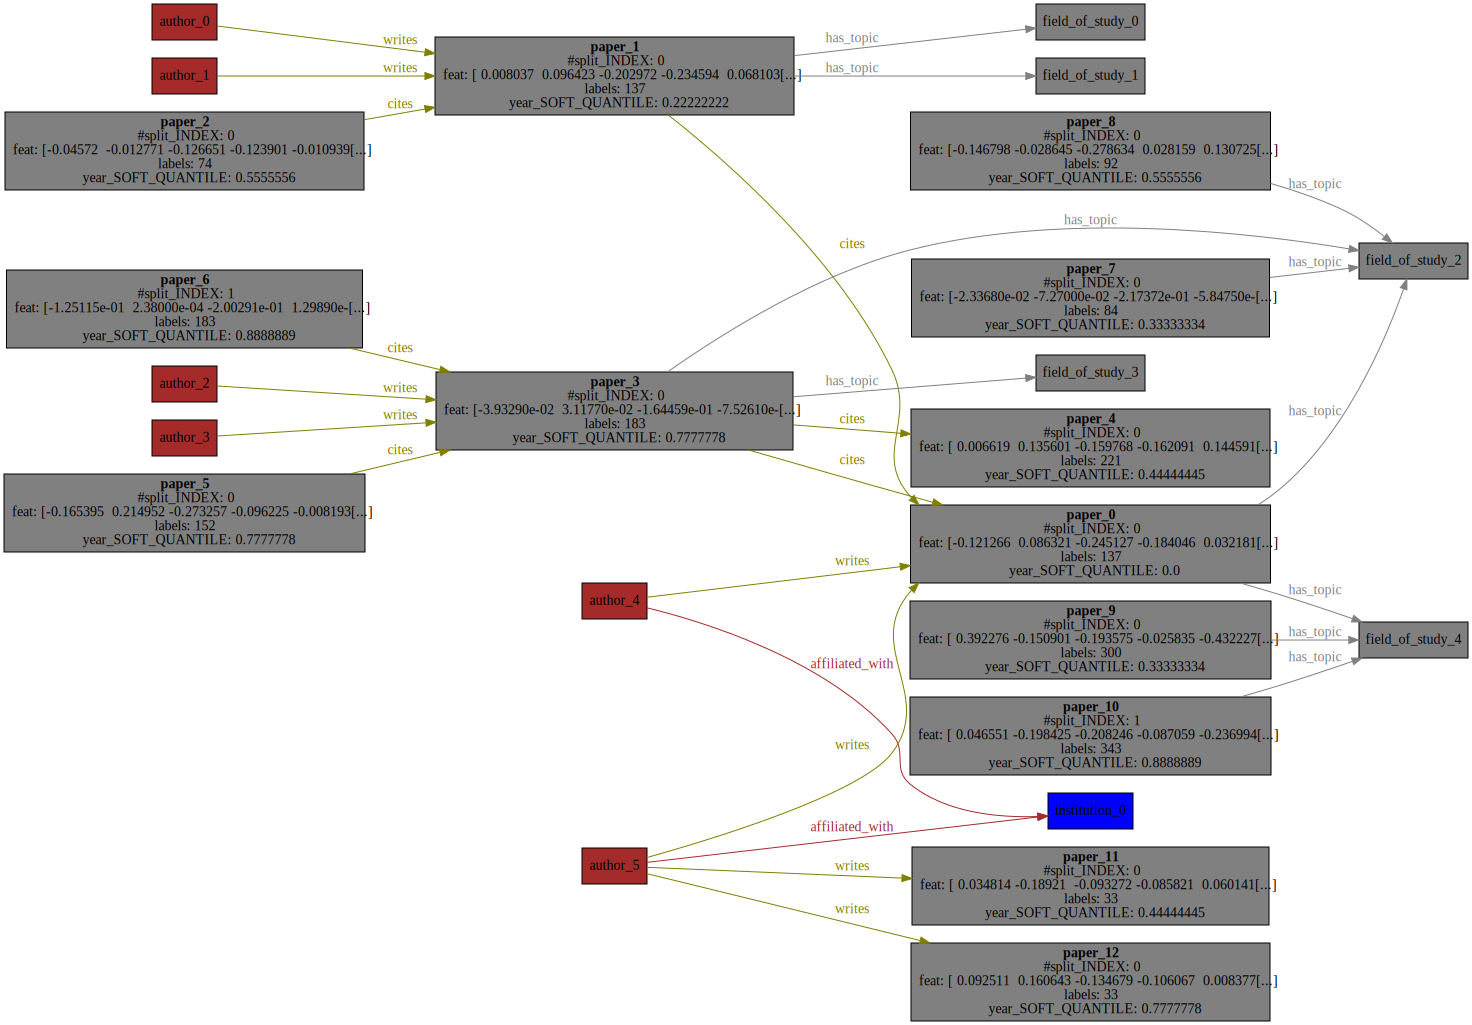

In [ ]:
def normalized_sample_generator(num_batches: int = 50):
  for raw_sample in sample_generator(num_batches):
    yield auto_normalizer.normalize_numpy(raw_sample)


# Test the generate by plotting a graph sample.
for sample in normalized_sample_generator():
  break
dgf.plot.plot_graph(sample, auto_normalizer.output_schema(), features=True)

## Distributed computation of feature statistics

If the graph is too large to be loaded into memory, you can compute feature
statistics with `dgf.beam.analyse.feature_statistics` or
`dgf.beam.analyse.feature_statistics_from_graphs` instead of
`dgf.analyse.feature_statistics` or
`dgf.analyse.feature_statistics_from_graphs`.

See `dgf/examples/feature_statistics_on_graph_samples.py` and
`dgf/examples/feature_statistics_on_hgraph.py` for full examples.

In [ ]:
from absl import flags
import apache_beam as beam
from apache_beam.options import pipeline_options
from google3.pipeline.flume.py import runner as flume_runner

# For the user: Comment / uncomment on of the block.
# Note: Defining the "flume_exec_mode" in the "PipelineOptions" does not work.

# Run the execution in-process. Great for debugging / iteration on small data.
# ===
flags.FLAGS.flume_exec_mode = "IN_PROCESS"
options = pipeline_options.PipelineOptions()

# Run the execution on Borg. Great for large data.
# ===
# flags.FLAGS.flume_exec_mode = "BORG"
# options = pipeline_options.PipelineOptions(
#     flume_borg_accounting_charged_user_name="simple-ml-accounting",
#     flume_borg_cells="is",
#     flume_use_batch_scheduler=True,
#     flume_batch_scheduler_strategy="RUN_SOON",
# )

Save our graph to disk. This will be the input of beam pipeline:

In [ ]:
graph_path = "/tmp/my_graph"
dgf.io.write_graph(graph, schema, path=graph_path)

GFGraph written from memory in 1.93 seconds


Let's compute the statistics:

**Warning:** This can take several minutes if running locally.

In [ ]:
with beam.Pipeline(runner=flume_runner.FlumeRunner(), options=options) as root:
  # Read the graph
  graph = dgf.beam.io.read_graph(root, "/tmp/my_graph")

  # Compute the statistics
  stats = dgf.beam.analyse.feature_statistics(graph)

  # Save the statistics to a json file
  dgf.beam.io.write_feature_statistics(stats, "/tmp/stats.json")

We can then load and inspect the statistics.

In [ ]:
feature_stats_from_beam = dgf.io.read_feature_statistics("/tmp/stats.json")
feature_stats_from_beam

GraphFeatureStatistics:
  Node Sets (4):
    'author':
      '#id': count=0, min=nan, max=nan
    'field_of_study':
      '#id': count=0, min=nan, max=nan
    'institution':
      '#id': count=0, min=nan, max=nan
    'paper':
      '#id': count=0, min=nan, max=nan
      '#split': count=736389, min=nan, max=nan, dictionary=(3)['train': 629571, 'valid': 64879, 'test': 41939]
      'feat': count=736389, min=nan, max=nan
      'labels': count=736389, min=0.0000, max=348.0000
      'year': count=736389, min=2010.0000, max=2019.0000, quantiles=(100)[2010.0000, 2010.0000, 2010.0000, ..., 2019.0000, 2019.0000, 2019.0000]